In [45]:
from langgraph.graph import StateGraph,START,END
from typing import Annotated,TypedDict
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage,AIMessage,HumanMessage

In [46]:
class ChatState(TypedDict):
    message: Annotated[list[BaseMessage],add_messages]

In [47]:
def test_interrupt(state: ChatState):
    decision = interrupt({
      'type':'approval',
      'reason':'model is about to answer a user question',
      'question':state['message'][-1].content,
      'instruction':'Approve this question? YES/NO'
  })
    # decision is the raw response from resume, so just compare it directly
    if decision.lower() == 'no':
        return {'message':[AIMessage(content='NOT approved')]}
    else:
        return {'message':[AIMessage(content='approved')]}

In [48]:
g = StateGraph(ChatState)
g.add_node("test_interrupt", test_interrupt)

g.add_edge(START, "test_interrupt")
g.add_edge('test_interrupt', END)
checkpointer = MemorySaver()

app  = g.compile(checkpointer=checkpointer)

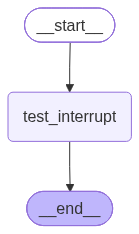

In [49]:
app

In [50]:
from langchain_core.messages import HumanMessage

config = {'configurable':{"thread_id":'1221'}}

initial_input={
    'message':[HumanMessage(content="What is the capital of France?")],
}


In [51]:
result = app.invoke(initial_input,config=config)


In [52]:
result['__interrupt__'][0].value

{'type': 'approval',
 'reason': 'model is about to answer a user question',
 'question': 'What is the capital of France?',
 'instruction': 'Approve this question? YES/NO'}

In [53]:
message = result['__interrupt__'][0].value
user_input = input(f'AIMessage: {message}\nYour response (yes/no): ')


In [54]:
type(user_input)

str

In [55]:
from langgraph.types import Command
final_result =  app.invoke(Command(resume=user_input), config=config)

In [56]:
print(final_result['message'][-1].content)


NOT approved
